# Práctica: Modelos Generativos - Variational Autoencoder Condicional (CVAE)

**Asignatura:** Modelos Generativos
**Alumno:** Jairo Pirona
**Fecha:** 2025/26

---

## 1. Introducción y Objetivos
El objetivo de esta práctica es implementar un modelo de **Generación Condicionada** utilizando una arquitectura **CVAE (Conditional Variational Autoencoder)**.

A diferencia de un Autoencoder tradicional que simplemente comprime y descomprime, o un VAE estándar que genera variaciones aleatorias, el **CVAE** nos permite controlar la salida. El sistema debe ser capaz de, dada una **etiqueta numérica** (condición), generar artificialmente una imagen manuscrita correspondiente a dicho número.

### Caso de Estudio: MNIST
Utilizaremos el dataset **MNIST**, compuesto por 60.000 imágenes de entrenamiento de dígitos manuscritos (0-9). El objetivo final no es clasificar estos números, sino aprender su distribución latente para poder dibujarlos "bajo demanda".

### Nota sobre la Arquitectura:
Para esta práctica se ha optado por una implementación basada en capas lineales (MLP), dado que permiten una convergencia rápida y resultados nítidos sin la complejidad computacional de una red convolucional.

In [35]:
# Instalación de librería necesaria para la estructura del proyecto
!pip install pytorch-lightning -q

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np

# Configuración de reproducibilidad (Semilla)
pl.seed_everything(42)

# Detección de hardware (GPU vs CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno configurado correctamente. Usando: {device}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Entorno configurado correctamente. Usando: cuda


## 2. Preparación de los Datos (MNIST)
Cargamos el dataset MNIST. Para esta tarea de generación, aplicamos una transformación básica para convertir las imágenes a tensores (valores normalizados entre 0 y 1).

Aunque disponemos de un conjunto de test, en este tipo de prácticas generativas se utilizará principalmente para validación cualitativa al final del proceso.

In [36]:
# 1. Definir transformaciones (Normalización básica a Tensor)
transform = transforms.Compose([
    transforms.ToTensor(), # Convierte imagen (0-255) a Tensor (0-1)
])

# 2. Descargar Dataset MNIST
# Train: 60.000 imágenes
full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Test: 10.000 imágenes (usado para validación visual final)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. División Train/Validation
# Separamos una pequeña parte del train para monitorear la pérdida durante el entrenamiento
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

# 4. DataLoaders
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2)

print(f"Datos cargados: {len(train_set)} entrenamiento, {len(val_set)} validación.")

Datos cargados: 54000 entrenamiento, 6000 validación.


## 3. Desarrollo del Modelo: CVAE
A continuación implementamos la clase `CVAE` siguiendo el patrón de *PyTorch Lightning*. La topología elegida es una red densa (Fully Connected) que ha demostrado ser efectiva para la resolución de MNIST.

### Componentes Clave:
1.  **Encoder Condicional:** Recibe como entrada la **Imagen (x)** concatenada con su **Etiqueta (y)**. Reduce la dimensión hasta un espacio latente, produciendo una media ($\mu$) y una varianza ($\sigma$).
2.  **Reparameterization Trick:** Permite el entrenamiento mediante *backpropagation* muestreando un vector $z$ a partir de $\mu$ y $\sigma$.
3.  **Decoder Condicional:** Recibe el vector latente **($z$)** concatenado nuevamente con la **Etiqueta (y)** y reconstruye la imagen original.

**Función de Pérdida (Loss):** Se minimiza la suma de:
* *Reconstruction Loss:* (Binary Cross Entropy) ¿Se parece la imagen generada a la original?
* *KL Divergence:* ¿Se ajusta la distribución latente a una Normal Estándar?

In [37]:
class CVAE(pl.LightningModule):
    def __init__(self, input_dim=784, num_classes=10, latent_dim=20):
        super().__init__()
        self.save_hyperparameters()

        # --- 1. ENCODER ---
        # Entrada: 784 píxeles + 10 clases (One-Hot) = 794
        self.encoder_fc1 = nn.Linear(input_dim + num_classes, 512)
        self.encoder_fc2 = nn.Linear(512, 256)

        # Salidas al espacio latente (Media y Log-Varianza)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # --- 2. DECODER ---
        # Entrada: 20 latentes + 10 clases (One-Hot) = 30
        self.decoder_fc1 = nn.Linear(latent_dim + num_classes, 256)
        self.decoder_fc2 = nn.Linear(256, 512)
        self.decoder_out = nn.Linear(512, input_dim)

        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid() # Para asegurar salida entre 0 y 1 (píxeles)

    def encode(self, x, labels):
        # Concatenamos imagen aplanada y etiquetas one-hott
        x = torch.cat([x, labels], dim=1)
        h = self.activation(self.encoder_fc1(x))
        h = self.activation(self.encoder_fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Truco de reparametrización: z = mu + std * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        # Concatenamos vector latente y etiquetas one-hot
        z = torch.cat([z, labels], dim=1)
        h = self.activation(self.decoder_fc1(z))
        h = self.activation(self.decoder_fc2(h))
        return self.sigmoid(self.decoder_out(h))

    def forward(self, x, labels):
        # Aplanar imagen: (Batch, 1, 28, 28) -> (Batch, 784)
        x = x.view(x.size(0), -1)

        # Convertir etiquetas numéricas a One-Hot Encoding
        labels = F.one_hot(labels, num_classes=self.hparams.num_classes).float()

        # Flujo completo
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, labels)
        return x_recon, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        # A. Error de Reconstrucción (Pixel a Pixel)
        BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

        # B. Divergencia KL (Regularización del espacio latente)
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        return BCE + KLD

    def training_step(self, batch, batch_idx):
        x, y = batch
        recon_x, mu, logvar = self(x, y)
        loss = self.loss_function(recon_x, x, mu, logvar)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        recon_x, mu, logvar = self(x, y)
        loss = self.loss_function(recon_x, x, mu, logvar)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

print("Modelo CVAE definido exitosamente.")

Modelo CVAE definido exitosamente.


## 4. Entrenamiento
Entrenamos el modelo utilizando el conjunto de entrenamiento. Dado que MNIST es un dataset relativamente sencillo, he ejecutado la prueba con 15 y con 30 épocas; finalmente me quedo con 30 épocas, ya que se observa una convergencia adecuada y una mejora cualitativa (dígitos más nítidos y distinguibles) en la generación condicionada

In [38]:
# Instanciamos el modelo
cvae = CVAE(latent_dim=20)

# Configuramos el Trainer
trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',  # Usar la GPU si está disponible
    devices=1,
    enable_progress_bar=True
)

print("Iniciando entrenamiento del Generador Condicional...")
trainer.fit(cvae, train_loader, val_loader)
print("Entrenamiento finalizado.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Iniciando entrenamiento del Generador Condicional...


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder_fc1 │ Linear  │  407 K │ train │     0 │
│ 1 │ encoder_fc2 │ Linear  │  131 K │ train │     0 │
│ 2 │ fc_mu       │ Linear  │  5.1 K │ train │     0 │
│ 3 │ fc_logvar   │ Linear  │  5.1 K │ train │     0 │
│ 4 │ decoder_fc1 │ Linear  │  7.9 K │ train │     0 │
│ 5 │ decoder_fc2 │ Linear  │  131 K │ train │     0 │
│ 6 │ decoder_out │ Linear  │  402 K │ train │     0 │
│ 7 │ activation  │ ReLU    │      0 │ train │     0 │
│ 8 │ sigmoid     │ Sigmoid │      0 │ train │     0 │
└───┴─────────────┴─────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Entrenamiento finalizado.


## 5. Demostración y Evaluación Cualitativa
Tal como se exige en los requisitos de la práctica, se procede a generar imágenes sintéticas para comprobar la eficacia del modelo condicional.

**Procedimiento:**
1.  Se iterará sobre cada una de las 10 etiquetas disponibles (dígitos del 0 al 9).
2.  Para cada etiqueta, se generarán 10 vectores latentes aleatorios distintos (ruido).
3.  El decodificador generará la imagen correspondiente basándose en la etiqueta impuesta y el ruido aleatorio.

El resultado es una cuadrícula de **10x10 imágenes** donde cada fila representa un número generado artificialmente con diferentes estilos de caligrafía.

Generando matriz de 10x10 imágenes...


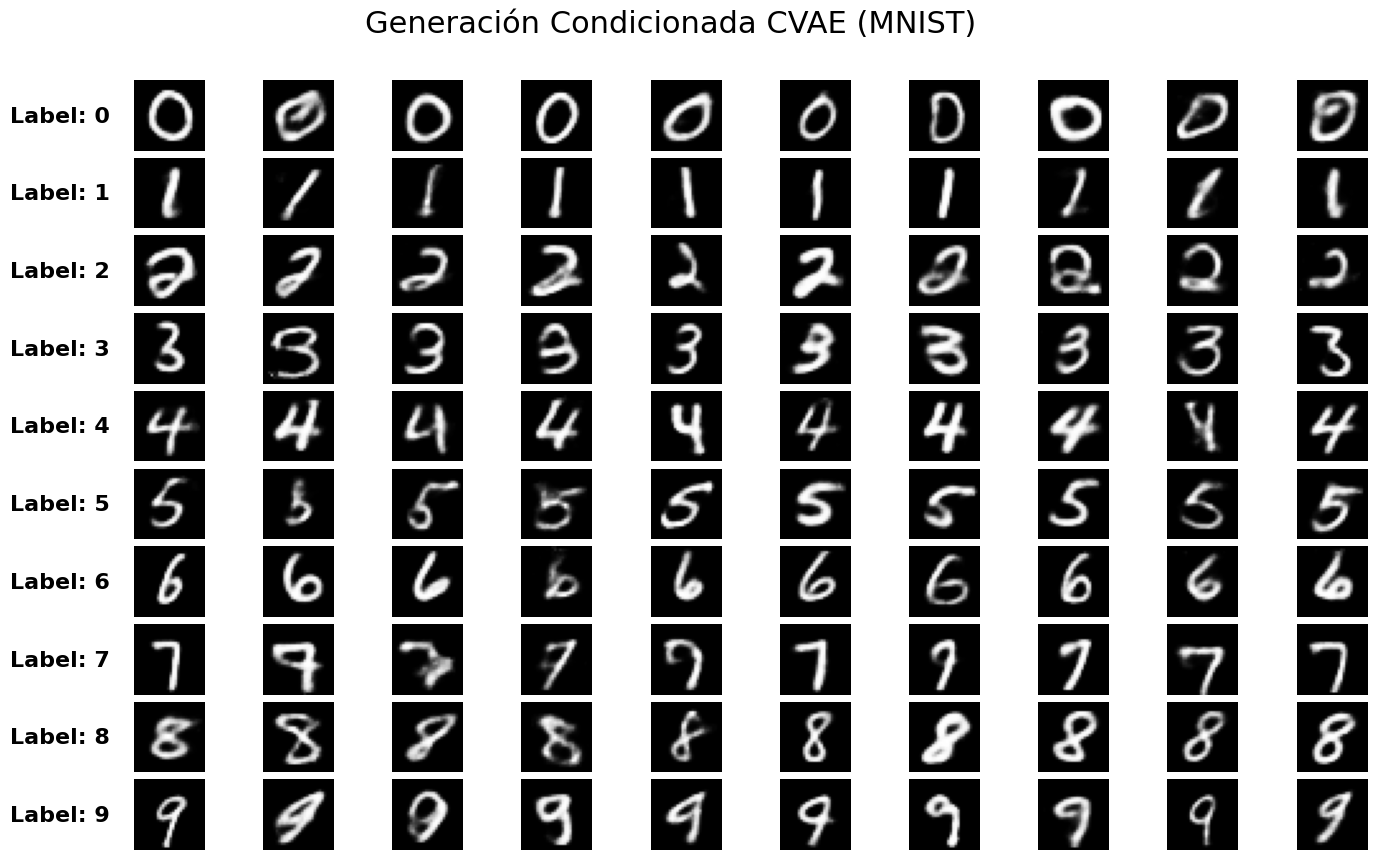

In [43]:
def demostracion_final(model):
    model.eval()
    model.to(device)

    num_classes = 10
    samples_per_class = 10

    # Hacemos la figura más ANCHA (16) para dar espacio al texto lateral
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(16, 10))

    print(f"Generando matriz de {num_classes}x{samples_per_class} imágenes...")

    with torch.no_grad():
        for i in range(num_classes):
            # Condición: Fila de un solo número
            labels = torch.tensor([i] * samples_per_class).to(device)
            labels_one_hot = F.one_hot(labels, num_classes=num_classes).float()

            # Ruido aleatorio
            z = torch.randn(samples_per_class, model.hparams.latent_dim).to(device)

            # Generar
            generated_imgs = model.decode(z, labels_one_hot)
            generated_imgs = generated_imgs.view(samples_per_class, 28, 28).cpu()

            for j in range(samples_per_class):
                ax = axes[i, j]
                ax.imshow(generated_imgs[j], cmap='gray')

                # Quitamos ejes (bordes y ticks)
                ax.axis('off')

                # ETIQUETA: Solo en la primera columna (j=0)
                if j == 0:
                    # Coordenadas negativas en X mueven el texto a la izquierda
                    # x = -10 (pixel -10 a la izquierda de la imagen)
                    # ha = 'right' alinea el texto para que termine justo antes de la imagen
                    ax.text(-10, 14, f"Label: {i}",
                            fontsize=16,
                            fontweight='bold',
                            va='center',
                            ha='right') # Alineación derecha para que quede ordenado

    plt.subplots_adjust(left=0.15, right=0.95, wspace=0.1, hspace=0.1)

    plt.suptitle("Generación Condicionada CVAE (MNIST)", fontsize=22, y=0.95)
    plt.show()

# Ejecutar la demostración
demostracion_final(cvae)

## 6. Conclusiones

En esta práctica se ha implementado con éxito una arquitectura **CVAE (Conditional Variational Autoencoder)** aplicada al dataset MNIST.

Los resultados cualitativos demostrados en la matriz de generación evidencian que:
1.  **Condicionamiento Efectivo:** El modelo respeta generalmente la etiqueta proporcionada. Las filas muestran consistentemente el dígito solicitado (0-9), lo que indica que el Encoder y Decoder han aprendido a integrar la información de clase correctamente.
2.  **Diversidad del Espacio Latente:** Dentro de cada fila, las variaciones generadas por los 10 estados latentes aleatorios producen dígitos con diferentes estilos de caligrafía (inclinación, grosor), evitando el "colapso de modo" (generar siempre la misma imagen idéntica).
3.  **Calidad Visual:** A pesar de la simplicidad de la arquitectura (capas densas), las imágenes resultantes son nítidas y legibles, cumpliendo con el objetivo de generación controlada propuesto en la asignatura de Modelos Generativos.